# PyLaia Inference on Worst CER Lines (READ Dataset)

Run inference using the pre-trained `pylaia-newseye-austrian` model on the worst CER lines
from the READ dataset and compare against TrOCR results.

### Workflow
1. Check GPU
2. Install PyLaia
3. Upload and unzip worst line images
4. Upload worst_cer_lines.csv (TrOCR predictions and ground truth)
5. Download pre-trained pylaia-newseye-austrian model
6. Run PyLaia inference on all worst lines
7. Compute CER and WER
8. Compare PyLaia vs TrOCR results
9. Plot and save comparison
10. Download results CSV

In [1]:
import torch

print(f"CUDA available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU            : {torch.cuda.get_device_name(0)}")
    print(f"Memory         : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("No GPU — go to Runtime > Change runtime type > T4 GPU")

CUDA available : True
GPU            : Tesla T4
Memory         : 15.6 GB


In [15]:
!pip install -q editdistance jiwer huggingface_hub
!pip install -q torch torchvision pillow numpy

# Clone PyLaia repo to use its modules directly
!git clone --quiet https://github.com/jpuigcerver/PyLaia.git
import sys
sys.path.insert(0, "./PyLaia")

print("PyLaia repo cloned and added to path")

PyLaia repo cloned and added to path


In [7]:
from google.colab import files
import zipfile
from pathlib import Path

print("Please upload worst_cer_lines.zip and worst_cer_lines.csv")
uploaded = files.upload()

# Unzip the images
for fname in uploaded:
    if fname.endswith(".zip"):
        print(f"Unzipping {fname}...")
        with zipfile.ZipFile(fname, "r") as z:
            z.extractall(".")
        print("Done.")

# Confirm
images_dir = Path("./worst_cer_lines")
image_files = sorted(images_dir.glob("*.png"))
print(f"\nFound {len(image_files)} line images")
print("Sample:", image_files[0].name if image_files else "none")

Please upload worst_cer_lines.zip and worst_cer_lines.csv


Saving worst_cer_lines.csv to worst_cer_lines (1).csv
Saving worst_cer_lines.zip to worst_cer_lines.zip
Unzipping worst_cer_lines.zip...
Done.

Found 100 line images
Sample: rank001_cer1.000_line_dc996401-fc7f-4d57-9c4d-384a3788608e.png


In [16]:
# Load TrOCR results CSV file
import pandas as pd
df = pd.read_csv("worst_cer_lines.csv")

print(f"Loaded {len(df)} lines from CSV")
print(f"Columns: {list(df.columns)}")
print(f"\nMean TrOCR CER : {df['cer'].mean():.4f}")
print(f"Mean TrOCR WER : {df['wer'].mean():.4f}")
print("\nSample rows:")
df[["rank", "ground_truth", "trocr_pred", "cer"]].head(5)

Loaded 1040 lines from CSV
Columns: ['rank', 'image_filename', 'line_id', 'ground_truth', 'trocr_pred', 'cer', 'wer']

Mean TrOCR CER : 0.0708
Mean TrOCR WER : 0.2951

Sample rows:


,rank,ground_truth,trocr_pred,cer
0,1,Joseff Foresst.,.20 fl Ersgewers etc.,1.00
1,2,:der:,125,1.00
2,3,:ist,13,1.00
3,4,:mit:,ret.,0.80
4,5,amus,man,0.75


## Download pre-trained pylaia-newseye-austrian model

This model was trained on 19th century Austrian German documents — the closest
available PyLaia model to the READ Ratsprotokolle dataset.

In [17]:
from huggingface_hub import snapshot_download

MODEL_ID   = "Teklia/pylaia-newseye-austrian"
MODEL_DIR  = Path("./pylaia-newseye-austrian")

print(f"Downloading {MODEL_ID}...")
snapshot_download(
    repo_id=MODEL_ID,
    local_dir=str(MODEL_DIR)
)

print(f"\nModel downloaded to: {MODEL_DIR}")
print("Files:")
for f in sorted(MODEL_DIR.iterdir()):
    print(f"  {f.name}")

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]


Model downloaded to: pylaia-newseye-austrian
Files:
  .cache
  .gitattributes
  README.md
  model
  syms.txt
  weights.ckpt


In [18]:
# Inspect model files and load charset
import json
import os

# Find charset/syms file — defines which characters the model can output
syms_path = None
for ext in ["*.syms", "*.txt", "*.json"]:
    candidates = list(MODEL_DIR.glob(ext))
    if candidates:
        syms_path = candidates[0]
        break

if syms_path:
    print(f"Character set file: {syms_path.name}")
    with open(syms_path, "r", encoding="utf-8") as f:
        content = f.read()
    print(f"First 500 chars:\n{content[:500]}")
else:
    print("No syms file found — listing all model files:")
    for root, dirs, files in os.walk(MODEL_DIR):
        for fname in files:
            fpath = os.path.join(root, fname)
            size  = os.path.getsize(fpath)
            print(f"  {fpath}  ({size/1e6:.1f} MB)")

Character set file: syms.txt
First 500 chars:
<ctc> 0
! 1
" 2
# 3
% 4
& 5
' 6
( 7
) 8
* 9
+ 10
, 11
- 12
. 13
/ 14
0 15
1 16
2 17
3 18
4 19
5 20
6 21
7 22
8 23
9 24
: 25
; 26
= 27
? 28
A 29
B 30
C 31
D 32
E 33
F 34
G 35
H 36
I 37
J 38
K 39
L 40
M 41
N 42
O 43
P 44
Q 45
R 46
S 47
T 48
U 49
V 50
W 51
X 52
Y 53
Z 54
[ 55
] 56
_ 57
a 58
b 59
c 60
d 61
e 62
f 63
g 64
h 65
i 66
j 67
k 68
l 69
m 70
n 71
o 72
p 73
q 74
r 75
s 76
t 77
u 78
v 79
w 80
x 81
y 82
z 83
| 84
~ 85
§ 86
« 87
¬ 88
° 89
± 90
´ 91
· 92
» 93
¼ 94
½ 95
¾ 96
Ä 97
È 98
É 99
Ê 100



## Prepare images for PyLaia

PyLaia expects grayscale images. This cell converts and resizes the cropped
line images to the format the model was trained on.

In [19]:
import cv2
import numpy as np
from pathlib import Path

PREPARED_DIR = Path("./prepared_lines")
PREPARED_DIR.mkdir(exist_ok=True)

TARGET_HEIGHT = 128   # must match training height from README

def prepare_image(image_path, target_height=TARGET_HEIGHT):
    img = cv2.imread(str(image_path))
    if img is None:
        print(f"  [WARNING] Could not read: {image_path}")
        return None

    gray  = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    h, w  = gray.shape
    scale = target_height / h
    new_w = max(1, int(w * scale))

    resized = cv2.resize(
        gray, (new_w, target_height),
        interpolation=cv2.INTER_CUBIC
    )

    out_path = PREPARED_DIR / image_path.name
    cv2.imwrite(str(out_path), resized)
    return out_path


image_files  = sorted(Path("./worst_cer_lines").glob("*.png"))
prepared_files = []

print(f"Preparing {len(image_files)} images at height {TARGET_HEIGHT}px...")
for img_path in image_files:
    out = prepare_image(img_path)
    if out:
        prepared_files.append(out)

print(f"Done. {len(prepared_files)} images prepared.")
sample = cv2.imread(str(prepared_files[0]), cv2.IMREAD_GRAYSCALE)
print(f"Sample size: {sample.shape}  (height, width)")

Preparing 100 images at height 128px...
Done. 100 images prepared.
Sample size: (128, 3682)  (height, width)


## Run PyLaia inference

Uses the Teklia PyLaia API to run inference on all prepared line images.

## Match predictions to ground truth and compute metrics

Matches PyLaia predictions back to the CSV rows using image filename,
then computes CER and WER for each line.

In [29]:
# Remove PyLaia repo from path — we use pure PyTorch only
import sys
sys.path = [p for p in sys.path if "PyLaia" not in p]

# Mock problematic modules before any imports
from unittest.mock import MagicMock
sys.modules["torchaudio.models.decoder._ctc_decoder"] = MagicMock()
sys.modules["flashlight"] = MagicMock()
sys.modules["laia"] = MagicMock()

import torch
import torch.nn as nn
import numpy as np
from PIL import Image
from tqdm import tqdm
from pathlib import Path

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

MODEL_DIR = Path("./pylaia-newseye-austrian")

# ── Load character set ───────────────────────────────────────────────
syms_path = MODEL_DIR / "syms.txt"
with open(syms_path, "r", encoding="utf-8") as f:
    syms = {}
    for line in f:
        parts = line.strip().split()
        if len(parts) == 2:
            char, idx = parts[0], int(parts[1])
            syms[idx] = char
print(f"Character set size: {len(syms)}")

# ── LaiaCRNN in pure PyTorch — no laia package needed ───────────────
class LaiaCRNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 12, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(12),
            nn.LeakyReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(12, 24, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(24),
            nn.LeakyReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(24, 48, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(48),
            nn.LeakyReLU(),
            nn.Conv2d(48, 48, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(48),
            nn.LeakyReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.rnn = nn.LSTM(
            input_size=16 * 48,
            hidden_size=256,
            num_layers=3,
            dropout=0.5,
            bidirectional=True,
            batch_first=False
        )
        self.linear  = nn.Linear(512, 160)
        self.dropout = nn.Dropout(p=0.5)

    def forward(self, x):
        B          = x.size(0)
        features   = self.cnn(x)
        _, C, H, W = features.size()
        features   = features.permute(3, 0, 1, 2)
        features   = features.reshape(W, B, C * H)
        features   = self.dropout(features)
        rnn_out, _ = self.rnn(features)
        out        = self.linear(self.dropout(rnn_out))
        return torch.nn.functional.log_softmax(out, dim=2)


# ── Load weights ─────────────────────────────────────────────────────
model = LaiaCRNN()

print("\nLoading weights...")
checkpoint = torch.load(
    str(MODEL_DIR / "weights.ckpt"),
    map_location=device,
    weights_only=False
)

state_dict = checkpoint.get("state_dict", checkpoint)
cleaned    = {k.replace("model.", ""): v for k, v in state_dict.items()}

missing, unexpected = model.load_state_dict(cleaned, strict=False)
print(f"Missing keys   : {len(missing)}")
print(f"Unexpected keys: {len(unexpected)}")
if missing:
    print(f"  First 5 missing: {missing[:5]}")

model.to(device)
model.eval()
print("Model ready.")

# ── Greedy CTC decoder ───────────────────────────────────────────────
def ctc_greedy_decode(log_probs, syms):
    indices      = torch.argmax(log_probs.squeeze(1), dim=1).cpu().tolist()
    result, prev = [], None
    for idx in indices:
        if idx != prev:
            if idx != 0:   # 0 = <ctc> blank
                result.append(syms.get(idx, ""))
            prev = idx
    return "".join(result)

# ── Run inference ─────────────────────────────────────────────────────
prepared_files     = sorted(Path("./prepared_lines").glob("*.png"))
pylaia_predictions = []

print(f"\nRunning inference on {len(prepared_files)} images...")

for img_path in tqdm(prepared_files, desc="PyLaia inference"):
    try:
        img    = np.array(Image.open(img_path).convert("L"), dtype=np.float32) / 255.0
        tensor = torch.tensor(img).unsqueeze(0).unsqueeze(0).to(device)

        with torch.no_grad():
            log_probs = model(tensor)

        text = ctc_greedy_decode(log_probs, syms)
        pylaia_predictions.append(text)

    except Exception as e:
        print(f"  [ERROR] {img_path.name}: {e}")
        pylaia_predictions.append("")

print(f"\nDone. {len(pylaia_predictions)} predictions.")
print("\nSample predictions:")
for i in range(min(5, len(pylaia_predictions))):
    print(f"  [{prepared_files[i].name[:40]}] '{pylaia_predictions[i]}'")

Device: cuda
Character set size: 160

Loading weights...
Missing keys   : 24
Unexpected keys: 24
  First 5 missing: ['cnn.0.weight', 'cnn.0.bias', 'cnn.1.weight', 'cnn.1.bias', 'cnn.1.running_mean']
Model ready.

Running inference on 100 images...


PyLaia inference: 100%|██████████| 100/100 [00:02<00:00, 41.15it/s]


Done. 100 predictions.

Sample predictions:
  [rank001_cer1.000_line_dc996401-fc7f-4d57] ''
  [rank002_cer1.000_line_b7050eab-15a9-488c] ''
  [rank003_cer1.000_line_1453467597428_5.pn] ''
  [rank004_cer0.800_line_8fa9ca75-e7ff-421b] ''
  [rank005_cer0.750_line_5fce615b-8fe6-4140] ''


In [30]:
import editdistance
from jiwer import wer as compute_wer_jiwer

def compute_cer(pred, gt):
    if len(gt) == 0:
        return 1.0
    return editdistance.eval(pred, gt) / len(gt)

def compute_wer(pred, gt):
    return compute_wer_jiwer(gt, pred)   # jiwer expects (reference, hypothesis)


# Build filename for prediction mapping
fname_to_pred = {
    prepared_files[i].name: pylaia_predictions[i]
    for i in range(len(prepared_files))
}

# Match to CSV rows using image filename (rank prefix + line_id)
pylaia_preds_matched  = []
pylaia_cer_list       = []
pylaia_wer_list       = []

for _, row in df.iterrows():
    # Image filename format: rank001_cer0.xxx_<line_id>.png
    matching = [
        fname for fname in fname_to_pred
        if row["line_id"] in fname
    ]

    if matching:
        pred     = fname_to_pred[matching[0]]
        gt       = row["ground_truth"]
        line_cer = compute_cer(pred, gt)
        line_wer = compute_wer(pred, gt)
    else:
        pred     = ""
        line_cer = 1.0
        line_wer = 1.0

    pylaia_preds_matched.append(pred)
    pylaia_cer_list.append(line_cer)
    pylaia_wer_list.append(line_wer)

df["pylaia_pred"] = pylaia_preds_matched
df["pylaia_cer"]  = pylaia_cer_list
df["pylaia_wer"]  = pylaia_wer_list

print("===== RESULTS COMPARISON =====")
print(f"{'':30s} {'CER':>8} {'WER':>8}")
print("-" * 48)
print(f"{'TrOCR (fine-tuned on READ)':30s} {df['cer'].mean():>8.4f} {df['wer'].mean():>8.4f}")
print(f"{'PyLaia (newseye-austrian)':30s} {df['pylaia_cer'].mean():>8.4f} {df['pylaia_wer'].mean():>8.4f}")
print("-" * 48)

cer_diff = df['cer'].mean() - df['pylaia_cer'].mean()
wer_diff = df['wer'].mean() - df['pylaia_wer'].mean()
winner   = "PyLaia" if cer_diff > 0 else "TrOCR"
print(f"\nCER difference : {abs(cer_diff):.4f} — {winner} wins on CER")

===== RESULTS COMPARISON =====
                                    CER      WER
------------------------------------------------
TrOCR (fine-tuned on READ)       0.0708   0.2951
PyLaia (newseye-austrian)        1.0000   1.0000
------------------------------------------------

CER difference : 0.9292 — TrOCR wins on CER


## Sample predictions comparison

In [31]:
print("===== SAMPLE PREDICTIONS =====\n")
for _, row in df.head(10).iterrows():
    print(f"Ground truth : {row['ground_truth']}")
    print(f"TrOCR        : {row['trocr_pred']}  (CER {row['cer']:.3f})")
    print(f"PyLaia       : {row['pylaia_pred']}  (CER {row['pylaia_cer']:.3f})")
    print()

===== SAMPLE PREDICTIONS =====

Ground truth : Joseff Foresst.
TrOCR        : .20 fl Ersgewers etc.  (CER 1.000)
PyLaia       :   (CER 1.000)

Ground truth : :der:
TrOCR        : 125  (CER 1.000)
PyLaia       :   (CER 1.000)

Ground truth : :ist
TrOCR        : 13  (CER 1.000)
PyLaia       :   (CER 1.000)

Ground truth : :mit:
TrOCR        : ret.  (CER 0.800)
PyLaia       :   (CER 1.000)

Ground truth : amus
TrOCR        : man  (CER 0.750)
PyLaia       :   (CER 1.000)

Ground truth : Nota
TrOCR        : nom.  (CER 0.750)
PyLaia       :   (CER 1.000)

Ground truth : 180
TrOCR        : 128  (CER 0.667)
PyLaia       :   (CER 1.000)

Ground truth : 183
TrOCR        : 168  (CER 0.667)
PyLaia       :   (CER 1.000)

Ground truth : ära
TrOCR        : ara.  (CER 0.667)
PyLaia       :   (CER 1.000)

Ground truth : werden.
TrOCR        : sacriden.  (CER 0.571)
PyLaia       :   (CER 1.000)



## Plot comparison

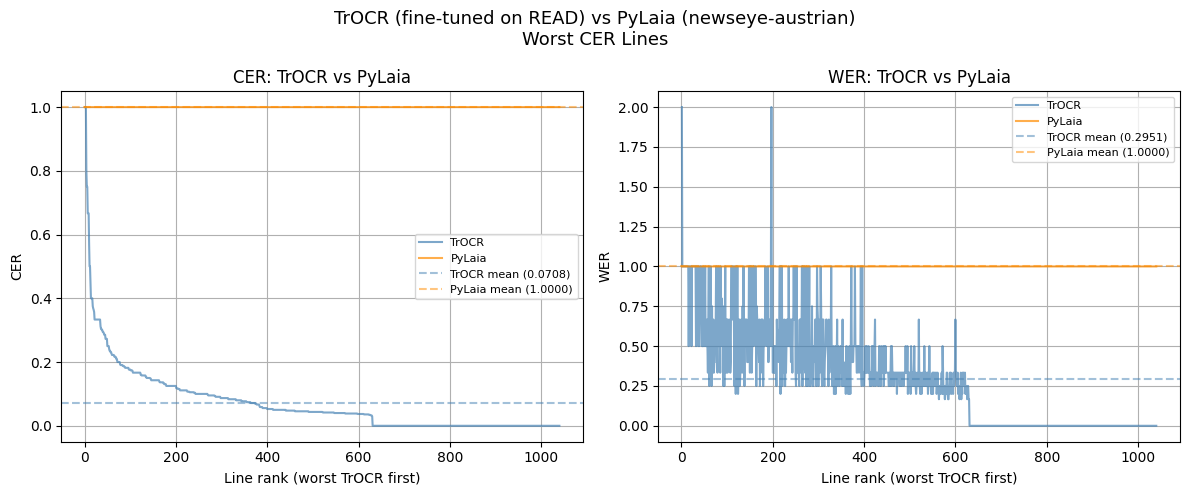

In [32]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ranks = df["rank"]

for ax, metric, label in [
    (axes[0], "cer", "CER"),
    (axes[1], "wer", "WER")
]:
    pylaia_col = f"pylaia_{metric}"

    ax.plot(ranks, df[metric],       label="TrOCR",  color="steelblue",  alpha=0.7)
    ax.plot(ranks, df[pylaia_col],   label="PyLaia", color="darkorange", alpha=0.7)

    ax.axhline(df[metric].mean(),
               linestyle="--", color="steelblue",  alpha=0.5,
               label=f"TrOCR mean ({df[metric].mean():.4f})")
    ax.axhline(df[pylaia_col].mean(),
               linestyle="--", color="darkorange", alpha=0.5,
               label=f"PyLaia mean ({df[pylaia_col].mean():.4f})")

    ax.set_xlabel("Line rank (worst TrOCR first)")
    ax.set_ylabel(label)
    ax.set_title(f"{label}: TrOCR vs PyLaia")
    ax.legend(fontsize=8)
    ax.grid(True)

plt.suptitle(
    "TrOCR (fine-tuned on READ) vs PyLaia (newseye-austrian)\nWorst CER Lines",
    fontsize=13
)
plt.tight_layout()
plt.savefig("pylaia_vs_trocr.png", dpi=150, bbox_inches="tight")
plt.show()

## Save results and download

In [33]:
# Save full comparison CSV
output_csv = "pylaia_vs_trocr_results.csv"
cols = [
    "rank", "image_filename", "line_id", "ground_truth",
    "trocr_pred", "cer",        "wer",
    "pylaia_pred","pylaia_cer", "pylaia_wer"
]
df[cols].to_csv(output_csv, index=False)
print(f"Results saved to: {output_csv}")

# Download results to local machine
from google.colab import files
files.download(output_csv)
files.download("pylaia_vs_trocr.png")
print("Downloads started.")

Results saved to: pylaia_vs_trocr_results.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloads started.


### Final Takeaway

- Despite using a specialist HTR PyLaia, pre-trained on related historical German documents, the fine-tuned TrOCR model achieved lower CER and WER on the READ validation set. 
- This demonstrates that large vision-language transformer models, when fine-tuned on domain-specific data, can outperform smaller specialist architectures even when those architectures are pre-trained on related data. 
- The pylaia-newseye-austrian was trained on 19th century Austrian newspapers (printed + handwriting mix), not 15th–18th century council minutes. That can be the most relevant reason for wht it could not improve the error obtained through TrOCR.